In [1]:
from dotenv import load_dotenv
import os
import torch
from torch.distributed.tensor.parallel import loss_parallel
from torch.nn import functional as F
import torch.nn as nn
from tqdm import trange

#from prepare_data import PreparedDataset
from prepare_data import ds_train, ds_test, Tkn, dl_train, dl_test

load_dotenv()

# MODEL WEIGHTS
DIM_IMAGE_EMBEDDING = 512
DIM_ATTENTION = 128
D_PIC = 400
N_HEAD_ATTENTION = 32

# PICTURE
N_CONTEXT = 768  # num of patched in picture
W = int(os.getenv("W"))
H = int(os.getenv("H"))
KERNEL = 20

# TEXT PARAMETERS
MAX_LEN_OF_TEXT_CONTEXT = 188 + 1  # 187 - max len of tokens sequence (mean text in utf-8). 1 - special token for start of sequence
DIM_TEXT_EMBEDDING = 128
DIM_TEXT_ATTENTION = 64
N_HEAD_LATEX_ATTENTION = 32
VOCAB_SIZE = 303

# CROSS-MECHANISM PARAMETERS
DIM_CROSS_EMBEDDING = 512
N_HEAD_CROSS_ATTENTION = 32
DIM_CROSS_ATTENTION = 128

device = "cuda" if torch.cuda.is_available() else "cpu"


@torch.no_grad()
def precompute_theta_2D_per_frequencies(head_size: int, theta=10000.0):
    m_x = torch.arange(0, W // KERNEL).repeat(H // KERNEL).to(device)
    m_y = torch.arange(0, H // KERNEL).repeat_interleave(W // KERNEL).to(device)
    theta_pairs_numerator = torch.arange(0, head_size // 2, 2).float()
    theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    freqs_x = torch.outer(m_x, theta).float()
    freqs_y = torch.outer(m_y, theta).float()
    freqs_complex_x = torch.polar(torch.ones_like(freqs_x), freqs_x)
    freqs_complex_y = torch.polar(torch.ones_like(freqs_y), freqs_y)
    return freqs_complex_x, freqs_complex_y  # (T, head_size // 2)

    # theta_pairs_numerator = torch.arange(0, head_size, 2).float() # i of each pair in emb
    # theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    # m = torch.arange(m, device=device)
    # freqs = torch.outer(m, theta).float()
    # freqs_complex = torch.polar(torch.ones_like(freqs), freqs) # convert to complex space based on Euler's formula e ^ (it)
    # return freqs_complex #(T, head_size // 2)


def apply_rotary_2D_embeddings(x: torch.Tensor, freqs_complex_x: torch.Tensor, freqs_complex_y: torch.Tensor):
    v_x, v_y = torch.chunk(x, 2, dim=-1)  # each: (B, T, head_size // 2)
    v_x_complex = torch.view_as_complex(v_x.float().reshape(*v_x.shape[:-1], -1, 2))  # (B, T, head_size // 4)
    v_y_complex = torch.view_as_complex(v_y.float().reshape(*v_y.shape[:-1], -1, 2))  # (B, T, head_size // 4)
    freqs_complex_x = freqs_complex_x.unsqueeze(0)
    freqs_complex_y = freqs_complex_y.unsqueeze(0)
    v_x_rotated = v_x_complex * freqs_complex_x
    v_y_rotated = v_y_complex * freqs_complex_y
    v_x_out = torch.view_as_real(v_x_rotated)  # (B, T, head_size // 4, 2)
    v_y_out = torch.view_as_real(v_y_rotated)  # (B, T, head_size // 4, 2)
    v_x_out = v_x_out.reshape(*v_x.shape)
    v_y_out = v_y_out.reshape(*v_y.shape)
    x_out = torch.cat([v_x_out, v_y_out], dim=-1)
    return x_out.type_as(x).to(device)

    # x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2)) # (B, T, head_size // 2)
    # freqs_complex = freqs_complex.unsqueeze(0) # (1, T, head_size // 2)
    # x_rotated = x_complex * freqs_complex
    # x_out = torch.view_as_real(x_rotated) #(B, T, head_size // 2, 2)
    # x_out = x_out.reshape(*x.shape)
    # return x_out.type_as(x).to(device)


@torch.no_grad()
def precompute_theta_1D_per_frequencies(head_size: int, theta=10000.0, m=MAX_LEN_OF_TEXT_CONTEXT):
    theta_pairs_numerator = torch.arange(0, head_size, 2).float()  # i of each pair in emb
    theta = 1.0 / (theta ** (2 * theta_pairs_numerator / head_size)).to(device)
    m = torch.arange(m, device=device)
    freqs = torch.outer(m, theta).float()
    freqs_complex = torch.polar(torch.ones_like(freqs),
                                freqs)  # convert to complex space based on Euler's formula e ^ (it)
    return freqs_complex  # (T, head_size // 2)


def apply_rotary_1D_embeddings(x: torch.Tensor, freqs_complex):
    B, T, C = x.size()
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))  # (B, T, head_size // 2)
    freqs_complex = freqs_complex[:T, :].unsqueeze(0)  # (1, T, head_size // 2) T = T_latex
    x_rotated = x_complex * freqs_complex
    x_out = torch.view_as_real(x_rotated)  # (B, T, head_size // 2, 2)
    x_out = x_out.reshape(*x.shape)
    return x_out.type_as(x).to(device)


class AttentionHead(nn.Module):
    def __init__(self, head_size, freqs_complex_x: torch.Tensor,
                 freqs_complex_y: torch.Tensor):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex_x, self.freqs_complex_y = freqs_complex_x, freqs_complex_y
        self.key = nn.Linear(DIM_IMAGE_EMBEDDING, head_size, bias=False)
        self.query = nn.Linear(DIM_IMAGE_EMBEDDING, head_size, bias=False)
        self.value = nn.Linear(DIM_IMAGE_EMBEDDING, head_size, bias=False)

    def forward(self, x):
        B, T, C = x.shape  # (batch, count of elements, count of features)
        k = self.key(x)  # (B, T, head_size)
        k = apply_rotary_2D_embeddings(k, self.freqs_complex_x, self.freqs_complex_y)

        q = self.query(x)  # (B, T, head_size)
        q = apply_rotary_2D_embeddings(q, self.freqs_complex_x, self.freqs_complex_y)

        v = self.value(x)  # (B, T, head_size)
        wei = (q @ k.transpose(-2, -1) / (C ** 0.5))  # (B, T, T)
        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        return out  # (B, T, head_size)


class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex_x, self.freqs_complex_y = precompute_theta_2D_per_frequencies(DIM_ATTENTION)
        self.heads = nn.ModuleList(
            [AttentionHead(DIM_ATTENTION, self.freqs_complex_x, self.freqs_complex_y) for i in range(N_HEAD_ATTENTION)])
        self.proj = nn.Linear(N_HEAD_ATTENTION * DIM_ATTENTION, DIM_IMAGE_EMBEDDING)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out  # (B, T, DIM_IMAGE_EMBEDDING)


class FeedForward(nn.Module):
    def __init__(self, embedding_in, embedding_out=None):
        if embedding_out == None:
            embedding_out = embedding_in
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_in, embedding_in * 4),
            nn.ReLU(),
            nn.Linear(embedding_in * 4, embedding_out)
        )

    def forward(self, x):
        return self.net(x)


class ResViTBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention()
        self.mlp = FeedForward(DIM_IMAGE_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)

    def forward(self, x):
        x = x + self.att(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x  # (B, T, DIM_IMAGE_EMBEDDING)


class AttentionHead_Latex_withMask(nn.Module):
    def __init__(self, head_size,
                 freqs_complex: torch.Tensor):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex = freqs_complex
        self.key = nn.Linear(DIM_TEXT_EMBEDDING, head_size, bias=False)
        self.query = nn.Linear(DIM_TEXT_EMBEDDING, head_size, bias=False)
        self.value = nn.Linear(DIM_TEXT_EMBEDDING, head_size, bias=False)

    def forward(self, x_text_emb, x_latex_mask):
        B, T, C = x_text_emb.shape  # (batch, count of elements, count of features)
        k = self.key(x_text_emb)  # (B, T, head_size)
        k = apply_rotary_1D_embeddings(k, self.freqs_complex)

        q = self.query(x_text_emb)  # (B, T, head_size)
        q = apply_rotary_1D_embeddings(q, self.freqs_complex)

        v = self.value(x_text_emb)  # (B, T, head_size)
        wei = (q @ k.transpose(-2, -1) / (C ** 0.5))  # (B, T, T)
        trill = torch.tril(torch.ones((T, T))).to(device)
        wei = wei.masked_fill(trill == 0, float("-inf"))  # trial mask
        wei = wei.masked_fill(x_latex_mask.unsqueeze(1) == 0, float("-inf"))  # padding mask (by rows)
        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        return out  # (B, T, head_size)


class MultiHeadAttention_LaTeX(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex = precompute_theta_1D_per_frequencies(DIM_TEXT_ATTENTION)
        self.heads = nn.ModuleList([AttentionHead_Latex_withMask(DIM_TEXT_ATTENTION, self.freqs_complex) for i in
                                    range(N_HEAD_LATEX_ATTENTION)])
        self.proj = nn.Linear(N_HEAD_LATEX_ATTENTION * DIM_TEXT_ATTENTION, DIM_TEXT_EMBEDDING)

    def forward(self, x_text_emb, x_latex_mask):
        out = torch.cat([h(x_text_emb, x_latex_mask) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out  # (B, T, DIM_TEXT_EMBEDDING)


class ResLaTeXBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention_LaTeX()
        self.mlp = FeedForward(DIM_TEXT_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_TEXT_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_TEXT_EMBEDDING)

    def forward(self, X):  # x_text_emb, x_latex_mask
        x_text_emb, x_latex_mask = X
        x = x_text_emb + self.att(self.ln1(x_text_emb), x_latex_mask)
        x = x_text_emb + self.mlp(self.ln2(x))
        return x  # (B, T, DIM_TEXT_EMBEDDING)


class Cross_AttentionHead_withMask(nn.Module):
    def __init__(self, head_size, freqs_complex_latex, freqs_complex_image_x,
                 freqs_complex_image_y):  # patch dim - dim of embedding space, head_size - dim of head space
        super().__init__()
        self.freqs_complex = freqs_complex_latex
        self.freqs_complex_image_x = freqs_complex_image_x
        self.freqs_complex_image_y = freqs_complex_image_y

        self.key = nn.Linear(DIM_IMAGE_EMBEDDING, head_size, bias=False)  # (B, T1, head_size)
        self.query = nn.Linear(DIM_TEXT_EMBEDDING, head_size, bias=False)  # (B, T2, head_size)
        self.value = nn.Linear(DIM_IMAGE_EMBEDDING, head_size, bias=False)  # (B, T1, head_size)

    def forward(self, x_image, x_text_emb, x_latex_mask):
        B, T, C = x_image.shape  # (batch, count of elements, count of features)

        k = self.key(x_image)  # (B, T_k, head_size)
        k = apply_rotary_2D_embeddings(k, self.freqs_complex_image_x, self.freqs_complex_image_y)

        q = self.query(x_text_emb)  # (B, T_q, head_size)
        q = apply_rotary_1D_embeddings(q, self.freqs_complex)

        v = self.value(x_image)  # (B, T_k, head_size)
        wei = (q @ k.transpose(-2, -1) / (C ** 0.5))  # (B, T_q, T_k)


        softwei = F.softmax(wei, dim=-1)
        out = softwei @ v
        return out  # (B, T_q, head_size)


class Cross_MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.freqs_complex_latex = precompute_theta_1D_per_frequencies(DIM_CROSS_ATTENTION)
        self.freqs_complex_image_x, self.freqs_complex_image_y = precompute_theta_2D_per_frequencies(
            DIM_CROSS_ATTENTION)

        self.heads = nn.ModuleList([Cross_AttentionHead_withMask(DIM_CROSS_ATTENTION, self.freqs_complex_latex,
                                                                 self.freqs_complex_image_x, self.freqs_complex_image_y)
                                    for i in range(N_HEAD_CROSS_ATTENTION)])
        self.proj = nn.Linear(N_HEAD_CROSS_ATTENTION * DIM_CROSS_ATTENTION, DIM_CROSS_EMBEDDING)

    def forward(self, x_image, x_latex, x_latex_mask):
        out = torch.cat([h(x_image, x_latex, x_latex_mask) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out  # (B, T_latex, DIM_CROSS_EMBEDDING)


class CrossAttentionBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = Cross_MultiHeadAttention()
        self.mlp = FeedForward(DIM_CROSS_EMBEDDING)
        self.ln1 = nn.LayerNorm(DIM_IMAGE_EMBEDDING)
        self.ln2 = nn.LayerNorm(DIM_TEXT_EMBEDDING)
        self.proj_latex = FeedForward(DIM_TEXT_EMBEDDING, embedding_out=DIM_CROSS_EMBEDDING)

    def forward(self, X):
        x_latex, x_image, x_latex_mask = X
        # x_latex (B, 190, DIM_TEXT_EMBEDDING)
        # x_image (B, T=768, DIM_IMAGE, DIM_IMAGE_EMBEDDING)
        x_latex = self.ln2(x_latex)
        x_latex_projected = self.proj_latex(x_latex)
        x = x_latex_projected + self.att(self.ln1(x_image), x_latex, x_latex_mask)  # (B, T_latex=190, DIM_CROSS_EMBEDDING)
        x = x + self.mlp(x)
        return x  # (B, T_latex, DIM_CROSS_EMBEDDING)


class FormulaAI(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_to_emb = nn.Linear(D_PIC, DIM_IMAGE_EMBEDDING)
        self.VIT_transformers = nn.Sequential(
            ResViTBlock(),
            ResViTBlock(),
        )
        self.latex_transformers = nn.Sequential(
            ResLaTeXBlock()
        )
        self.token_embedding_table = nn.Embedding(VOCAB_SIZE + 1, DIM_TEXT_EMBEDDING)
        self.cross_attention = nn.Sequential(
            CrossAttentionBlock()
        )
        self.final_mlp = FeedForward(DIM_CROSS_EMBEDDING, VOCAB_SIZE + 1)

    def forward(self, X, mode="train"):

        if mode == "train":
            x_image, x_latex, y = X
            y = y.to(device)
        else:
            x_image, x_latex = X
        x_image = x_image.to(device)
        x_latex = x_latex.to(device)


        x_image_emb = self.image_to_emb(x_image)
        x_image_VIT = self.VIT_transformers(x_image_emb)  # (B, T_image, DIM_IMAGE_EMBEDDING)

        # x_latex:
        # [[301, 178, 204, 303, 303, .., 303]]     [302] - not here, because it's x_latex, not target

        x_latex_mask = Tkn.mask_padding(x_latex).to(device)
        x_text_emb = self.token_embedding_table(x_latex)  # (B, T, DIM_TEXT_EMBEDDING)
        x_processed_latex = self.latex_transformers((x_text_emb, x_latex_mask))  # (B, T_latex, DIM_TEXT_EMBEDDING)
        logits = self.cross_attention(
            (x_processed_latex, x_image_VIT, x_latex_mask))  # (B, T_latex, DIM_CROSS_EMBEDDING)
        logits = self.final_mlp(logits)  # (B, T_latex, vocab_size)

        B, T_latex, voc = logits.shape

        if mode == "train":
            logits = logits.view(B * T_latex, voc)
            targets = y.view(B * T_latex)
            loss = F.cross_entropy(logits, targets, ignore_index=Tkn.padding)
        else:
            loss = None

        return logits, loss

    def generate(self, x, MAX_NUM_TOKENS):
        model.eval()
        x_image, idx = x
        idx = idx.to(device)
        x_image = x_image.to(device)
        # print(x_image.size())
        # print(idx.size())
        # (B, T) array of indices
        for _ in range(MAX_NUM_TOKENS):
            # get the predictions
            logits, loss = self((x_image, idx), mode="test") # (B, T, voc)
            logits = logits[:, -1, :] # (B, voc)
            probs = F.softmax(logits, dim=-1) # get probabilities 1: [0,5; 0,02 .. ] -> 1
            idx_next = torch.argmax(probs, dim=-1) # predict next token (B)
            idx = torch.cat((idx, idx_next.unsqueeze(0)), dim=1)
        return idx



# ---- TRAIN ----
model = FormulaAI().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
EPOCHS = 10
losses = []

загрузка датасета MathWriting-human...
датасет MathWriting-human загружен успешно


In [2]:
checkpoint = torch.load("checkpoints_18.03.26/checkpoint_Last.pt")
model.load_state_dict(checkpoint["model"])

<All keys matched successfully>

In [2]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 33,326,384


In [3]:
for sample in dl_train:
    print(sample)
    break


(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,

In [4]:
import matplotlib.pyplot as plt
import os
os.makedirs("checkpoints_25.03.26", exist_ok=True)


In [5]:
## TRAIN

cnt = 1
#N_STOP = 20

#if __name__ == "__main__":
def train():
    global cnt
    try:
        for epoch in range(EPOCHS):
            for sample in dl_train:
                logits, loss = model(sample)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
                # if cnt == N_STOP:
                #     break
                print(loss.item(), " ")
                cnt += 1
                if cnt % 10 == 0:
                    torch.save({
                        "epoch": epoch,
                        "step": cnt,
                        "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                    }, f"checkpoints_25.03.26/{epoch}_{cnt}_checkpoint.pt")
            # if cnt == N_STOP:
            #     break
    except KeyboardInterrupt:
        print("Saving before exit...")
        torch.save({
            "epoch": epoch,
            "step": cnt,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
        }, "checkpoints_25.03.26/checkpoint_Last.pt")



In [6]:
train()

5.732925891876221  
5.558829307556152  
5.3739824295043945  
5.155789852142334  
4.901140213012695  
4.798840522766113  
4.635703086853027  
4.567206859588623  
4.450345516204834  
4.43366003036499  
4.365915775299072  
4.398263454437256  
4.410211563110352  
4.362584590911865  
4.246038913726807  
4.297886371612549  
4.292551040649414  
4.294127464294434  
4.280762195587158  
4.26472282409668  
Saving before exit...


In [38]:
train()

4.2983856201171875  
4.365635871887207  
4.283515453338623  
4.274887561798096  
4.258316516876221  
4.2859673500061035  
4.270658016204834  
4.201965808868408  
4.239679336547852  
4.207757472991943  
4.1735005378723145  
4.209456920623779  
4.209818363189697  
4.151920795440674  
4.216549396514893  
4.205598831176758  
4.124222278594971  
4.195623397827148  
4.192099571228027  
4.07922887802124  
4.198734283447266  
4.237122058868408  
4.157438278198242  
4.146564960479736  
4.068099021911621  
3.9845011234283447  
4.1028828620910645  
4.088447093963623  
4.029079914093018  
4.039773941040039  
4.119081020355225  
4.031996250152588  
4.034214973449707  
4.058917999267578  
4.04148006439209  
4.022599220275879  
4.019441604614258  
3.9667654037475586  
3.9256062507629395  
4.006748676300049  
3.9491631984710693  
Saving before exit...


In [19]:
losses

[5.734379768371582,
 5.554236888885498,
 5.345703601837158,
 5.146026134490967,
 4.872678279876709,
 4.753793716430664,
 4.685861110687256,
 4.604040622711182,
 4.465956211090088,
 4.445108413696289,
 4.351897716522217,
 4.363656520843506,
 4.319024562835693,
 4.335620403289795,
 4.348776817321777]

In [16]:
model.parameters()

<generator object Module.parameters at 0x000001F7DFA39A80>

In [17]:
gradients_dict = {}
for name, param in model.named_parameters():
    if param.grad is not None:
        gradients_dict[name] = param.grad.clone()
    else:
        gradients_dict[name] = None

In [18]:
gradients_dict

{'image_to_emb.weight': tensor([[-5.0805e-05, -4.9741e-05, -4.8514e-05,  ..., -4.5492e-05,
          -4.5659e-05, -4.7981e-05],
         [-2.0558e-05, -1.9657e-05, -1.9803e-05,  ..., -2.0236e-05,
          -2.0164e-05, -1.8900e-05],
         [ 1.0335e-04,  1.0184e-04,  1.0160e-04,  ...,  1.0070e-04,
           1.0117e-04,  1.0150e-04],
         ...,
         [ 2.4391e-04,  2.4384e-04,  2.4428e-04,  ...,  2.3651e-04,
           2.3587e-04,  2.3537e-04],
         [-3.8974e-07, -4.5543e-07,  1.1145e-06,  ...,  9.1155e-07,
           5.3844e-07, -1.1161e-07],
         [ 2.7122e-05,  2.8015e-05,  2.9871e-05,  ...,  2.6702e-05,
           2.7085e-05,  2.6064e-05]], device='cuda:0'),
 'image_to_emb.bias': tensor([ 5.5212e-05, -1.4141e-04,  1.0829e-04, -1.6184e-05, -5.4012e-05,
         -3.0208e-04, -1.5755e-04, -1.1947e-04, -8.4877e-05,  1.1274e-04,
         -1.0763e-04, -1.3722e-04,  1.1516e-04, -1.0569e-04, -9.5525e-05,
         -8.2485e-05,  4.2221e-05,  1.8918e-04,  8.2474e-05, -1.1807e-0

In [19]:
gradients_dict.keys()

dict_keys(['image_to_emb.weight', 'image_to_emb.bias', 'VIT_transformers.0.att.heads.0.key.weight', 'VIT_transformers.0.att.heads.0.query.weight', 'VIT_transformers.0.att.heads.0.value.weight', 'VIT_transformers.0.att.heads.1.key.weight', 'VIT_transformers.0.att.heads.1.query.weight', 'VIT_transformers.0.att.heads.1.value.weight', 'VIT_transformers.0.att.heads.2.key.weight', 'VIT_transformers.0.att.heads.2.query.weight', 'VIT_transformers.0.att.heads.2.value.weight', 'VIT_transformers.0.att.heads.3.key.weight', 'VIT_transformers.0.att.heads.3.query.weight', 'VIT_transformers.0.att.heads.3.value.weight', 'VIT_transformers.0.att.heads.4.key.weight', 'VIT_transformers.0.att.heads.4.query.weight', 'VIT_transformers.0.att.heads.4.value.weight', 'VIT_transformers.0.att.heads.5.key.weight', 'VIT_transformers.0.att.heads.5.query.weight', 'VIT_transformers.0.att.heads.5.value.weight', 'VIT_transformers.0.att.heads.6.key.weight', 'VIT_transformers.0.att.heads.6.query.weight', 'VIT_transformers.0

In [24]:
gradients_dict["image_to_emb.weight"]

tensor([[-1.0793e-04, -1.0917e-04, -1.0955e-04,  ..., -1.2278e-04,
         -1.2188e-04, -1.2060e-04],
        [ 2.2417e-05,  2.3711e-05,  2.2351e-05,  ...,  3.6255e-05,
          3.6246e-05,  3.6942e-05],
        [-2.3258e-05, -2.3749e-05, -2.4120e-05,  ..., -1.7638e-05,
         -1.5866e-05, -1.3870e-05],
        ...,
        [ 2.0322e-04,  2.0587e-04,  2.0608e-04,  ...,  2.1468e-04,
          2.1376e-04,  2.1313e-04],
        [-1.7342e-04, -1.7430e-04, -1.7456e-04,  ..., -1.7774e-04,
         -1.7779e-04, -1.7552e-04],
        [-1.6832e-04, -1.6780e-04, -1.6702e-04,  ..., -1.6113e-04,
         -1.6183e-04, -1.6073e-04]], device='cuda:0')

In [20]:
def debug_gradients_simple(gradients_dict):
    fig, ax = plt.subplots()
    plt.figure(figsize=(20, 4))
    legends = []
    for layer, value in gradients_dict.items():
        temp = value.clone()
        temp = temp.to("cpu")
        hy, hx = torch.histogram(temp, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        plt.xscale('log')
        legends.append(f"layer: {layer}")

    #plt.legend(legends)
    plt.title("gradient distribution")


In [21]:
len(ds_train) / 64

3591.625

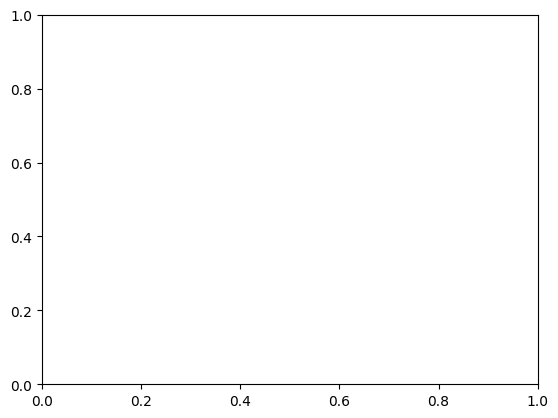

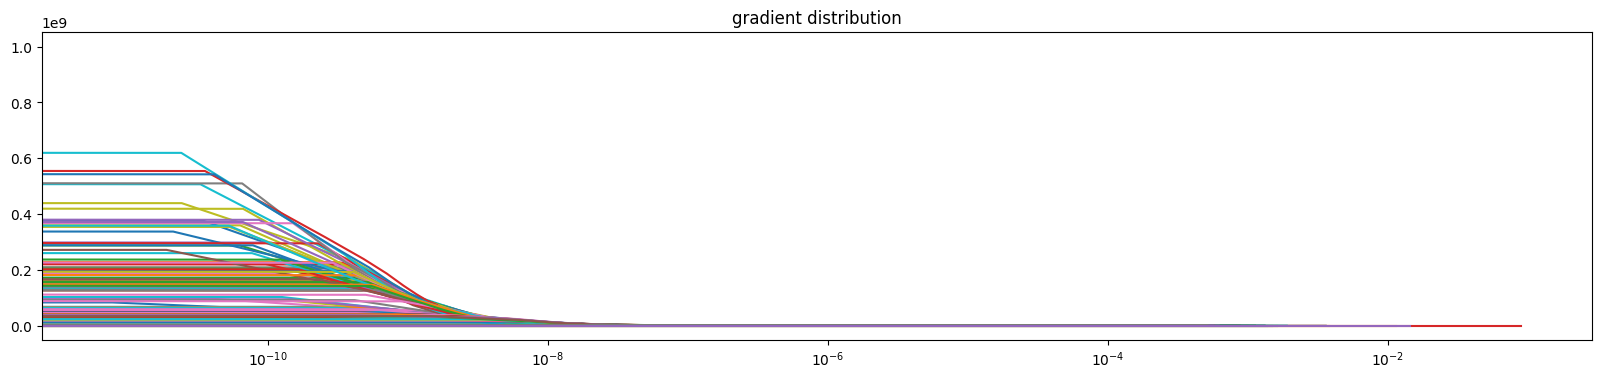

In [13]:
debug_gradients_simple(gradients_dict)

In [22]:
states = ['image_to_emb.weight', 'image_to_emb.bias', 'VIT_transformers.0.att.heads.0.key.weight', 'VIT_transformers.0.att.heads.0.query.weight', 'VIT_transformers.0.att.heads.0.value.weight', 'VIT_transformers.0.att.heads.1.key.weight', 'VIT_transformers.0.att.heads.1.query.weight', 'VIT_transformers.0.att.heads.1.value.weight', 'VIT_transformers.0.att.heads.2.key.weight', 'VIT_transformers.0.att.heads.2.query.weight', 'VIT_transformers.0.att.heads.2.value.weight', 'VIT_transformers.0.att.heads.3.key.weight', 'VIT_transformers.0.att.heads.3.query.weight', 'VIT_transformers.0.att.heads.3.value.weight', 'VIT_transformers.0.att.heads.4.key.weight', 'VIT_transformers.0.att.heads.4.query.weight', 'VIT_transformers.0.att.heads.4.value.weight', 'VIT_transformers.0.att.heads.5.key.weight', 'VIT_transformers.0.att.heads.5.query.weight', 'VIT_transformers.0.att.heads.5.value.weight', 'VIT_transformers.0.att.heads.6.key.weight', 'VIT_transformers.0.att.heads.6.query.weight', 'VIT_transformers.0.att.heads.6.value.weight', 'VIT_transformers.0.att.heads.7.key.weight', 'VIT_transformers.0.att.heads.7.query.weight', 'VIT_transformers.0.att.heads.7.value.weight', 'VIT_transformers.0.att.heads.8.key.weight', 'VIT_transformers.0.att.heads.8.query.weight', 'VIT_transformers.0.att.heads.8.value.weight', 'VIT_transformers.0.att.heads.9.key.weight', 'VIT_transformers.0.att.heads.9.query.weight', 'VIT_transformers.0.att.heads.9.value.weight', 'VIT_transformers.0.att.heads.10.key.weight', 'VIT_transformers.0.att.heads.10.query.weight', 'VIT_transformers.0.att.heads.10.value.weight', 'VIT_transformers.0.att.heads.11.key.weight', 'VIT_transformers.0.att.heads.11.query.weight', 'VIT_transformers.0.att.heads.11.value.weight', 'VIT_transformers.0.att.heads.12.key.weight', 'VIT_transformers.0.att.heads.12.query.weight', 'VIT_transformers.0.att.heads.12.value.weight', 'VIT_transformers.0.att.heads.13.key.weight', 'VIT_transformers.0.att.heads.13.query.weight', 'VIT_transformers.0.att.heads.13.value.weight', 'VIT_transformers.0.att.heads.14.key.weight', 'VIT_transformers.0.att.heads.14.query.weight', 'VIT_transformers.0.att.heads.14.value.weight', 'VIT_transformers.0.att.heads.15.key.weight', 'VIT_transformers.0.att.heads.15.query.weight', 'VIT_transformers.0.att.heads.15.value.weight', 'VIT_transformers.0.att.heads.16.key.weight', 'VIT_transformers.0.att.heads.16.query.weight', 'VIT_transformers.0.att.heads.16.value.weight', 'VIT_transformers.0.att.heads.17.key.weight', 'VIT_transformers.0.att.heads.17.query.weight', 'VIT_transformers.0.att.heads.17.value.weight', 'VIT_transformers.0.att.heads.18.key.weight', 'VIT_transformers.0.att.heads.18.query.weight', 'VIT_transformers.0.att.heads.18.value.weight', 'VIT_transformers.0.att.heads.19.key.weight', 'VIT_transformers.0.att.heads.19.query.weight', 'VIT_transformers.0.att.heads.19.value.weight', 'VIT_transformers.0.att.heads.20.key.weight', 'VIT_transformers.0.att.heads.20.query.weight', 'VIT_transformers.0.att.heads.20.value.weight', 'VIT_transformers.0.att.heads.21.key.weight', 'VIT_transformers.0.att.heads.21.query.weight', 'VIT_transformers.0.att.heads.21.value.weight', 'VIT_transformers.0.att.heads.22.key.weight', 'VIT_transformers.0.att.heads.22.query.weight', 'VIT_transformers.0.att.heads.22.value.weight', 'VIT_transformers.0.att.heads.23.key.weight', 'VIT_transformers.0.att.heads.23.query.weight', 'VIT_transformers.0.att.heads.23.value.weight', 'VIT_transformers.0.att.heads.24.key.weight', 'VIT_transformers.0.att.heads.24.query.weight', 'VIT_transformers.0.att.heads.24.value.weight', 'VIT_transformers.0.att.heads.25.key.weight', 'VIT_transformers.0.att.heads.25.query.weight', 'VIT_transformers.0.att.heads.25.value.weight', 'VIT_transformers.0.att.heads.26.key.weight', 'VIT_transformers.0.att.heads.26.query.weight', 'VIT_transformers.0.att.heads.26.value.weight', 'VIT_transformers.0.att.heads.27.key.weight', 'VIT_transformers.0.att.heads.27.query.weight', 'VIT_transformers.0.att.heads.27.value.weight', 'VIT_transformers.0.att.heads.28.key.weight', 'VIT_transformers.0.att.heads.28.query.weight', 'VIT_transformers.0.att.heads.28.value.weight', 'VIT_transformers.0.att.heads.29.key.weight', 'VIT_transformers.0.att.heads.29.query.weight', 'VIT_transformers.0.att.heads.29.value.weight', 'VIT_transformers.0.att.heads.30.key.weight', 'VIT_transformers.0.att.heads.30.query.weight', 'VIT_transformers.0.att.heads.30.value.weight', 'VIT_transformers.0.att.heads.31.key.weight', 'VIT_transformers.0.att.heads.31.query.weight', 'VIT_transformers.0.att.heads.31.value.weight', 'VIT_transformers.0.att.proj.weight', 'VIT_transformers.0.att.proj.bias', 'VIT_transformers.0.mlp.net.0.weight', 'VIT_transformers.0.mlp.net.0.bias', 'VIT_transformers.0.mlp.net.2.weight', 'VIT_transformers.0.mlp.net.2.bias', 'VIT_transformers.0.ln1.weight', 'VIT_transformers.0.ln1.bias', 'VIT_transformers.0.ln2.weight', 'VIT_transformers.0.ln2.bias', 'VIT_transformers.1.att.heads.0.key.weight', 'VIT_transformers.1.att.heads.0.query.weight', 'VIT_transformers.1.att.heads.0.value.weight', 'VIT_transformers.1.att.heads.1.key.weight', 'VIT_transformers.1.att.heads.1.query.weight', 'VIT_transformers.1.att.heads.1.value.weight', 'VIT_transformers.1.att.heads.2.key.weight', 'VIT_transformers.1.att.heads.2.query.weight', 'VIT_transformers.1.att.heads.2.value.weight', 'VIT_transformers.1.att.heads.3.key.weight', 'VIT_transformers.1.att.heads.3.query.weight', 'VIT_transformers.1.att.heads.3.value.weight', 'VIT_transformers.1.att.heads.4.key.weight', 'VIT_transformers.1.att.heads.4.query.weight', 'VIT_transformers.1.att.heads.4.value.weight', 'VIT_transformers.1.att.heads.5.key.weight', 'VIT_transformers.1.att.heads.5.query.weight', 'VIT_transformers.1.att.heads.5.value.weight', 'VIT_transformers.1.att.heads.6.key.weight', 'VIT_transformers.1.att.heads.6.query.weight', 'VIT_transformers.1.att.heads.6.value.weight', 'VIT_transformers.1.att.heads.7.key.weight', 'VIT_transformers.1.att.heads.7.query.weight', 'VIT_transformers.1.att.heads.7.value.weight', 'VIT_transformers.1.att.heads.8.key.weight', 'VIT_transformers.1.att.heads.8.query.weight', 'VIT_transformers.1.att.heads.8.value.weight', 'VIT_transformers.1.att.heads.9.key.weight', 'VIT_transformers.1.att.heads.9.query.weight', 'VIT_transformers.1.att.heads.9.value.weight', 'VIT_transformers.1.att.heads.10.key.weight', 'VIT_transformers.1.att.heads.10.query.weight', 'VIT_transformers.1.att.heads.10.value.weight', 'VIT_transformers.1.att.heads.11.key.weight', 'VIT_transformers.1.att.heads.11.query.weight', 'VIT_transformers.1.att.heads.11.value.weight', 'VIT_transformers.1.att.heads.12.key.weight', 'VIT_transformers.1.att.heads.12.query.weight', 'VIT_transformers.1.att.heads.12.value.weight', 'VIT_transformers.1.att.heads.13.key.weight', 'VIT_transformers.1.att.heads.13.query.weight', 'VIT_transformers.1.att.heads.13.value.weight', 'VIT_transformers.1.att.heads.14.key.weight', 'VIT_transformers.1.att.heads.14.query.weight', 'VIT_transformers.1.att.heads.14.value.weight', 'VIT_transformers.1.att.heads.15.key.weight', 'VIT_transformers.1.att.heads.15.query.weight', 'VIT_transformers.1.att.heads.15.value.weight', 'VIT_transformers.1.att.heads.16.key.weight', 'VIT_transformers.1.att.heads.16.query.weight', 'VIT_transformers.1.att.heads.16.value.weight', 'VIT_transformers.1.att.heads.17.key.weight', 'VIT_transformers.1.att.heads.17.query.weight', 'VIT_transformers.1.att.heads.17.value.weight', 'VIT_transformers.1.att.heads.18.key.weight', 'VIT_transformers.1.att.heads.18.query.weight', 'VIT_transformers.1.att.heads.18.value.weight', 'VIT_transformers.1.att.heads.19.key.weight', 'VIT_transformers.1.att.heads.19.query.weight', 'VIT_transformers.1.att.heads.19.value.weight', 'VIT_transformers.1.att.heads.20.key.weight', 'VIT_transformers.1.att.heads.20.query.weight', 'VIT_transformers.1.att.heads.20.value.weight', 'VIT_transformers.1.att.heads.21.key.weight', 'VIT_transformers.1.att.heads.21.query.weight', 'VIT_transformers.1.att.heads.21.value.weight', 'VIT_transformers.1.att.heads.22.key.weight', 'VIT_transformers.1.att.heads.22.query.weight', 'VIT_transformers.1.att.heads.22.value.weight', 'VIT_transformers.1.att.heads.23.key.weight', 'VIT_transformers.1.att.heads.23.query.weight', 'VIT_transformers.1.att.heads.23.value.weight', 'VIT_transformers.1.att.heads.24.key.weight', 'VIT_transformers.1.att.heads.24.query.weight', 'VIT_transformers.1.att.heads.24.value.weight', 'VIT_transformers.1.att.heads.25.key.weight', 'VIT_transformers.1.att.heads.25.query.weight', 'VIT_transformers.1.att.heads.25.value.weight', 'VIT_transformers.1.att.heads.26.key.weight', 'VIT_transformers.1.att.heads.26.query.weight', 'VIT_transformers.1.att.heads.26.value.weight', 'VIT_transformers.1.att.heads.27.key.weight', 'VIT_transformers.1.att.heads.27.query.weight', 'VIT_transformers.1.att.heads.27.value.weight', 'VIT_transformers.1.att.heads.28.key.weight', 'VIT_transformers.1.att.heads.28.query.weight', 'VIT_transformers.1.att.heads.28.value.weight', 'VIT_transformers.1.att.heads.29.key.weight', 'VIT_transformers.1.att.heads.29.query.weight', 'VIT_transformers.1.att.heads.29.value.weight', 'VIT_transformers.1.att.heads.30.key.weight', 'VIT_transformers.1.att.heads.30.query.weight', 'VIT_transformers.1.att.heads.30.value.weight', 'VIT_transformers.1.att.heads.31.key.weight', 'VIT_transformers.1.att.heads.31.query.weight', 'VIT_transformers.1.att.heads.31.value.weight', 'VIT_transformers.1.att.proj.weight', 'VIT_transformers.1.att.proj.bias', 'VIT_transformers.1.mlp.net.0.weight', 'VIT_transformers.1.mlp.net.0.bias', 'VIT_transformers.1.mlp.net.2.weight', 'VIT_transformers.1.mlp.net.2.bias', 'VIT_transformers.1.ln1.weight', 'VIT_transformers.1.ln1.bias', 'VIT_transformers.1.ln2.weight', 'VIT_transformers.1.ln2.bias', 'latex_transformers.0.att.heads.0.key.weight', 'latex_transformers.0.att.heads.0.query.weight', 'latex_transformers.0.att.heads.0.value.weight', 'latex_transformers.0.att.heads.1.key.weight', 'latex_transformers.0.att.heads.1.query.weight', 'latex_transformers.0.att.heads.1.value.weight', 'latex_transformers.0.att.heads.2.key.weight', 'latex_transformers.0.att.heads.2.query.weight', 'latex_transformers.0.att.heads.2.value.weight', 'latex_transformers.0.att.heads.3.key.weight', 'latex_transformers.0.att.heads.3.query.weight', 'latex_transformers.0.att.heads.3.value.weight', 'latex_transformers.0.att.heads.4.key.weight', 'latex_transformers.0.att.heads.4.query.weight', 'latex_transformers.0.att.heads.4.value.weight', 'latex_transformers.0.att.heads.5.key.weight', 'latex_transformers.0.att.heads.5.query.weight', 'latex_transformers.0.att.heads.5.value.weight', 'latex_transformers.0.att.heads.6.key.weight', 'latex_transformers.0.att.heads.6.query.weight', 'latex_transformers.0.att.heads.6.value.weight', 'latex_transformers.0.att.heads.7.key.weight', 'latex_transformers.0.att.heads.7.query.weight', 'latex_transformers.0.att.heads.7.value.weight', 'latex_transformers.0.att.heads.8.key.weight', 'latex_transformers.0.att.heads.8.query.weight', 'latex_transformers.0.att.heads.8.value.weight', 'latex_transformers.0.att.heads.9.key.weight', 'latex_transformers.0.att.heads.9.query.weight', 'latex_transformers.0.att.heads.9.value.weight', 'latex_transformers.0.att.heads.10.key.weight', 'latex_transformers.0.att.heads.10.query.weight', 'latex_transformers.0.att.heads.10.value.weight', 'latex_transformers.0.att.heads.11.key.weight', 'latex_transformers.0.att.heads.11.query.weight', 'latex_transformers.0.att.heads.11.value.weight', 'latex_transformers.0.att.heads.12.key.weight', 'latex_transformers.0.att.heads.12.query.weight', 'latex_transformers.0.att.heads.12.value.weight', 'latex_transformers.0.att.heads.13.key.weight', 'latex_transformers.0.att.heads.13.query.weight', 'latex_transformers.0.att.heads.13.value.weight', 'latex_transformers.0.att.heads.14.key.weight', 'latex_transformers.0.att.heads.14.query.weight', 'latex_transformers.0.att.heads.14.value.weight', 'latex_transformers.0.att.heads.15.key.weight', 'latex_transformers.0.att.heads.15.query.weight', 'latex_transformers.0.att.heads.15.value.weight', 'latex_transformers.0.att.heads.16.key.weight', 'latex_transformers.0.att.heads.16.query.weight', 'latex_transformers.0.att.heads.16.value.weight', 'latex_transformers.0.att.heads.17.key.weight', 'latex_transformers.0.att.heads.17.query.weight', 'latex_transformers.0.att.heads.17.value.weight', 'latex_transformers.0.att.heads.18.key.weight', 'latex_transformers.0.att.heads.18.query.weight', 'latex_transformers.0.att.heads.18.value.weight', 'latex_transformers.0.att.heads.19.key.weight', 'latex_transformers.0.att.heads.19.query.weight', 'latex_transformers.0.att.heads.19.value.weight', 'latex_transformers.0.att.heads.20.key.weight', 'latex_transformers.0.att.heads.20.query.weight', 'latex_transformers.0.att.heads.20.value.weight', 'latex_transformers.0.att.heads.21.key.weight', 'latex_transformers.0.att.heads.21.query.weight', 'latex_transformers.0.att.heads.21.value.weight', 'latex_transformers.0.att.heads.22.key.weight', 'latex_transformers.0.att.heads.22.query.weight', 'latex_transformers.0.att.heads.22.value.weight', 'latex_transformers.0.att.heads.23.key.weight', 'latex_transformers.0.att.heads.23.query.weight', 'latex_transformers.0.att.heads.23.value.weight', 'latex_transformers.0.att.heads.24.key.weight', 'latex_transformers.0.att.heads.24.query.weight', 'latex_transformers.0.att.heads.24.value.weight', 'latex_transformers.0.att.heads.25.key.weight', 'latex_transformers.0.att.heads.25.query.weight', 'latex_transformers.0.att.heads.25.value.weight', 'latex_transformers.0.att.heads.26.key.weight', 'latex_transformers.0.att.heads.26.query.weight', 'latex_transformers.0.att.heads.26.value.weight', 'latex_transformers.0.att.heads.27.key.weight', 'latex_transformers.0.att.heads.27.query.weight', 'latex_transformers.0.att.heads.27.value.weight', 'latex_transformers.0.att.heads.28.key.weight', 'latex_transformers.0.att.heads.28.query.weight', 'latex_transformers.0.att.heads.28.value.weight', 'latex_transformers.0.att.heads.29.key.weight', 'latex_transformers.0.att.heads.29.query.weight', 'latex_transformers.0.att.heads.29.value.weight', 'latex_transformers.0.att.heads.30.key.weight', 'latex_transformers.0.att.heads.30.query.weight', 'latex_transformers.0.att.heads.30.value.weight', 'latex_transformers.0.att.heads.31.key.weight', 'latex_transformers.0.att.heads.31.query.weight', 'latex_transformers.0.att.heads.31.value.weight', 'latex_transformers.0.att.proj.weight', 'latex_transformers.0.att.proj.bias', 'latex_transformers.0.mlp.net.0.weight', 'latex_transformers.0.mlp.net.0.bias', 'latex_transformers.0.mlp.net.2.weight', 'latex_transformers.0.mlp.net.2.bias', 'latex_transformers.0.ln1.weight', 'latex_transformers.0.ln1.bias', 'latex_transformers.0.ln2.weight', 'latex_transformers.0.ln2.bias', 'token_embedding_table.weight', 'cross_attention.0.att.heads.0.key.weight', 'cross_attention.0.att.heads.0.query.weight', 'cross_attention.0.att.heads.0.value.weight', 'cross_attention.0.att.heads.1.key.weight', 'cross_attention.0.att.heads.1.query.weight', 'cross_attention.0.att.heads.1.value.weight', 'cross_attention.0.att.heads.2.key.weight', 'cross_attention.0.att.heads.2.query.weight', 'cross_attention.0.att.heads.2.value.weight', 'cross_attention.0.att.heads.3.key.weight', 'cross_attention.0.att.heads.3.query.weight', 'cross_attention.0.att.heads.3.value.weight', 'cross_attention.0.att.heads.4.key.weight', 'cross_attention.0.att.heads.4.query.weight', 'cross_attention.0.att.heads.4.value.weight', 'cross_attention.0.att.heads.5.key.weight', 'cross_attention.0.att.heads.5.query.weight', 'cross_attention.0.att.heads.5.value.weight', 'cross_attention.0.att.heads.6.key.weight', 'cross_attention.0.att.heads.6.query.weight', 'cross_attention.0.att.heads.6.value.weight', 'cross_attention.0.att.heads.7.key.weight', 'cross_attention.0.att.heads.7.query.weight', 'cross_attention.0.att.heads.7.value.weight', 'cross_attention.0.att.heads.8.key.weight', 'cross_attention.0.att.heads.8.query.weight', 'cross_attention.0.att.heads.8.value.weight', 'cross_attention.0.att.heads.9.key.weight', 'cross_attention.0.att.heads.9.query.weight', 'cross_attention.0.att.heads.9.value.weight', 'cross_attention.0.att.heads.10.key.weight', 'cross_attention.0.att.heads.10.query.weight', 'cross_attention.0.att.heads.10.value.weight', 'cross_attention.0.att.heads.11.key.weight', 'cross_attention.0.att.heads.11.query.weight', 'cross_attention.0.att.heads.11.value.weight', 'cross_attention.0.att.heads.12.key.weight', 'cross_attention.0.att.heads.12.query.weight', 'cross_attention.0.att.heads.12.value.weight', 'cross_attention.0.att.heads.13.key.weight', 'cross_attention.0.att.heads.13.query.weight', 'cross_attention.0.att.heads.13.value.weight', 'cross_attention.0.att.heads.14.key.weight', 'cross_attention.0.att.heads.14.query.weight', 'cross_attention.0.att.heads.14.value.weight', 'cross_attention.0.att.heads.15.key.weight', 'cross_attention.0.att.heads.15.query.weight', 'cross_attention.0.att.heads.15.value.weight', 'cross_attention.0.att.heads.16.key.weight', 'cross_attention.0.att.heads.16.query.weight', 'cross_attention.0.att.heads.16.value.weight', 'cross_attention.0.att.heads.17.key.weight', 'cross_attention.0.att.heads.17.query.weight', 'cross_attention.0.att.heads.17.value.weight', 'cross_attention.0.att.heads.18.key.weight', 'cross_attention.0.att.heads.18.query.weight', 'cross_attention.0.att.heads.18.value.weight', 'cross_attention.0.att.heads.19.key.weight', 'cross_attention.0.att.heads.19.query.weight', 'cross_attention.0.att.heads.19.value.weight', 'cross_attention.0.att.heads.20.key.weight', 'cross_attention.0.att.heads.20.query.weight', 'cross_attention.0.att.heads.20.value.weight', 'cross_attention.0.att.heads.21.key.weight', 'cross_attention.0.att.heads.21.query.weight', 'cross_attention.0.att.heads.21.value.weight', 'cross_attention.0.att.heads.22.key.weight', 'cross_attention.0.att.heads.22.query.weight', 'cross_attention.0.att.heads.22.value.weight', 'cross_attention.0.att.heads.23.key.weight', 'cross_attention.0.att.heads.23.query.weight', 'cross_attention.0.att.heads.23.value.weight', 'cross_attention.0.att.heads.24.key.weight', 'cross_attention.0.att.heads.24.query.weight', 'cross_attention.0.att.heads.24.value.weight', 'cross_attention.0.att.heads.25.key.weight', 'cross_attention.0.att.heads.25.query.weight', 'cross_attention.0.att.heads.25.value.weight', 'cross_attention.0.att.heads.26.key.weight', 'cross_attention.0.att.heads.26.query.weight', 'cross_attention.0.att.heads.26.value.weight', 'cross_attention.0.att.heads.27.key.weight', 'cross_attention.0.att.heads.27.query.weight', 'cross_attention.0.att.heads.27.value.weight', 'cross_attention.0.att.heads.28.key.weight', 'cross_attention.0.att.heads.28.query.weight', 'cross_attention.0.att.heads.28.value.weight', 'cross_attention.0.att.heads.29.key.weight', 'cross_attention.0.att.heads.29.query.weight', 'cross_attention.0.att.heads.29.value.weight', 'cross_attention.0.att.heads.30.key.weight', 'cross_attention.0.att.heads.30.query.weight', 'cross_attention.0.att.heads.30.value.weight', 'cross_attention.0.att.heads.31.key.weight', 'cross_attention.0.att.heads.31.query.weight', 'cross_attention.0.att.heads.31.value.weight', 'cross_attention.0.att.proj.weight', 'cross_attention.0.att.proj.bias', 'cross_attention.0.mlp.net.0.weight', 'cross_attention.0.mlp.net.0.bias', 'cross_attention.0.mlp.net.2.weight', 'cross_attention.0.mlp.net.2.bias', 'cross_attention.0.ln1.weight', 'cross_attention.0.ln1.bias', 'cross_attention.0.ln2.weight', 'cross_attention.0.ln2.bias', 'final_mlp.net.0.weight', 'final_mlp.net.0.bias', 'final_mlp.net.2.weight', 'final_mlp.net.2.bias']

rendored_states = []
for i in states:
    rendored_states.append(i.split(".")[0])

rendored_states = list(set(rendored_states))


In [23]:
rendored_states

['final_mlp',
 'token_embedding_table',
 'image_to_emb',
 'VIT_transformers',
 'latex_transformers',
 'cross_attention']

In [24]:
states_without_finalmlp = ['token_embedding_table',
 'VIT_transformers',
 'cross_attention',
 'latex_transformers',
 'image_to_emb']

In [25]:

def debug_gradients(gradients_dict, rendored_states):
    fig, ax = plt.subplots()
    legends = []
    for state in rendored_states:  # График для каждого блока сети



        dict_for_layers = {}

        for layer, value in gradients_dict.items():
            # Проверяем, содержит ли название слоя текущее состояние
            if state in layer:

                temp = value.clone()
                temp = temp.to("cpu")
                if state in dict_for_layers:
                    dict_for_layers[state].append(temp.reshape(-1))
                else:
                    dict_for_layers[state] = [temp.reshape(-1)]

        for layer in dict_for_layers:
            temp = torch.cat(dict_for_layers[layer])
            hy, hx = torch.histogram(temp, density=True)
            ax.plot(hx[:-1].detach(), hy.detach(), alpha=0.7)  # alpha для наглядности
            ax.set_yscale('log')
            #line1, = ax.plot([1, 2, 3], label="Line 1", linestyle='--')
            legends.append(f"{layer}")

    plt.legend(legends, fontsize=8)  # меньший шрифт для легенды
    plt.title(f"Gradient distribution")
    plt.grid(True, alpha=0.3)  # добавляем сетку для удобства
    ax.set_xlim(-0.001, 0.001)
    plt.show()  # Показываем график перед следующим


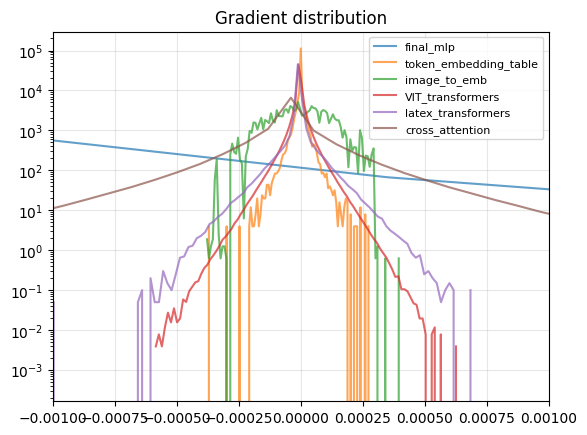

In [26]:
debug_gradients(gradients_dict, rendored_states)

In [10]:
import numpy as np

In [11]:
len(losses)

20

In [12]:
def show_loss(losses):
    plt.plot(np.arange(1., len(losses) + 1, 1), losses)
    plt.ylabel('NLL-loss')
    plt.xlabel('iteration of learning')
    plt.axis((0, len(losses), 0, 6))
    plt.show()

In [7]:
len(losses)

20

In [30]:
import pickle

with open('checkpoints_first/loss_logs.pkl', 'rb') as file:
    losses = pickle.load(file)

In [13]:
losses

[5.732925891876221,
 5.558829307556152,
 5.3739824295043945,
 5.155789852142334,
 4.901140213012695,
 4.798840522766113,
 4.635703086853027,
 4.567206859588623,
 4.450345516204834,
 4.43366003036499,
 4.365915775299072,
 4.398263454437256,
 4.410211563110352,
 4.362584590911865,
 4.246038913726807,
 4.297886371612549,
 4.292551040649414,
 4.294127464294434,
 4.280762195587158,
 4.26472282409668]

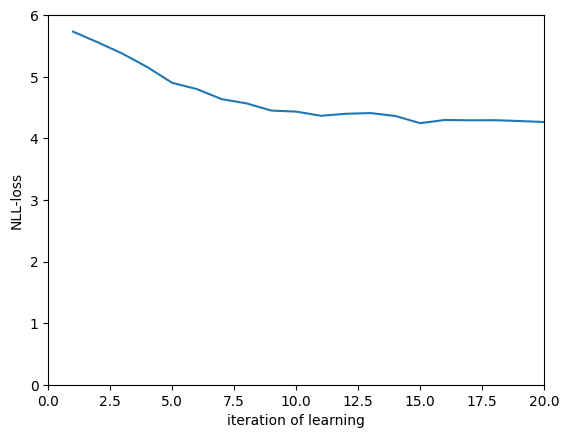

In [14]:
show_loss(losses)

In [15]:
import pickle

with open('checkpoints_25.03.26/loss_logs.pkl', 'wb') as file:
    pickle.dump(losses, file)

In [5]:
model

FormulaAI(
  (image_to_emb): Linear(in_features=400, out_features=512, bias=True)
  (VIT_transformers): Sequential(
    (0): ResViTBlock(
      (att): MultiHeadAttention(
        (heads): ModuleList(
          (0-31): 32 x AttentionHead(
            (key): Linear(in_features=512, out_features=128, bias=False)
            (query): Linear(in_features=512, out_features=128, bias=False)
            (value): Linear(in_features=512, out_features=128, bias=False)
          )
        )
        (proj): Linear(in_features=4096, out_features=512, bias=True)
      )
      (mlp): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): ReLU()
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (1): ResViTBlock(
      (att): MultiHeadAttention(
        (head

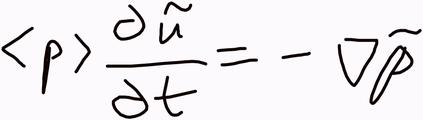

In [6]:
ds_train.dataset[300]["image"]

In [7]:
from torchvision import transforms
from prepare_data import SmartResizer

presee_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    SmartResizer(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [8]:
ds_train.dataset[300]["image"].size

(423, 120)

In [9]:
s_to_test = presee_transform(ds_train.dataset[300]["image"]).squeeze()

In [10]:
s_to_test[40]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 

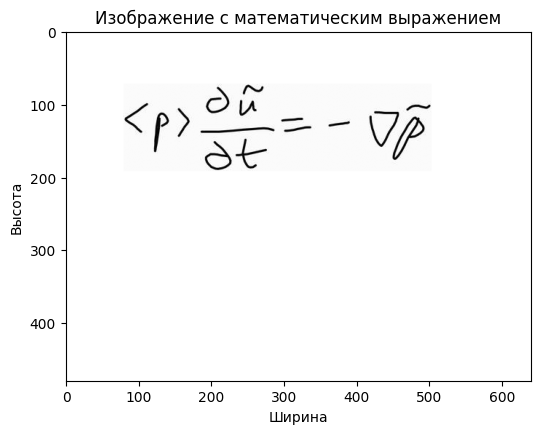

In [11]:
plt.figure(figsize=(6, 6))
plt.imshow(s_to_test, cmap='gray') # Отображаем данные с цветовой картой 'gray'
#plt.colorbar(label='Интенсивность пикселя')
plt.title('Изображение с математическим выражением')
plt.xlabel('Ширина')
plt.ylabel('Высота')
plt.show()

In [12]:
ds_train[300]

(tensor([[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 tensor([301,  92, 108,  97, 110, 103, 108, 101,  92, 114, 104, 111,  92, 259,
         110, 103, 108, 101, 263, 271,  97, 266, 105, 284,  92, 116, 105, 108,
         100, 295, 117, 280, 271,  97, 266, 105, 284,  32, 116, 281,  45,  92,
         110,  97,  98, 108,  97,  92, 116, 105, 108, 100, 295, 112, 125, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303

In [8]:
ds_train[300][0].unsqueeze(0).size()

torch.Size([1, 768, 400])

In [27]:
model.generate((ds_train[300][0].unsqueeze(0), torch.tensor([301]).unsqueeze(0)), 11)

tensor([[301, 263,  49, 125, 302, 125, 302, 125, 302, 125, 302, 125]],
       device='cuda:0')

In [72]:
ds_train[300]

(tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]),
 tensor([301,  92, 108,  97, 110, 103, 108, 101,  92, 114, 104, 111,  92, 259,
         110, 103, 108, 101, 263, 271,  97, 266, 105, 284,  92, 116, 105, 108,
         100, 295, 117, 280, 271,  97, 266, 105, 284,  32, 116, 281,  45,  92,
         110,  97,  98, 108,  97,  92, 116, 105, 108, 100, 295, 112, 125, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303,
         303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 303, 3

In [87]:
attention_matrixes = []

In [88]:
from contextlib import contextmanager
from typing import Callable, Tuple

def compute_attention_image_matrix(layer: torch.nn.Module, inputs: Tuple[torch.Tensor], _output: torch.Tensor):
    if type(layer) == AttentionHead:
        x_h = inputs[0]
        B, T, C = x_h.shape
        k_h = layer.key(x_h)
        k_h = apply_rotary_2D_embeddings(k_h, layer.freqs_complex_x, layer.freqs_complex_y)
        q_h = layer.query(x_h)
        q_h = apply_rotary_2D_embeddings(q_h, layer.freqs_complex_x, layer.freqs_complex_y)
        wei_h = (q_h @ k_h.transpose(-2, -1) / (C ** 0.5))
        attention_matrixes.append(wei_h)


@contextmanager
def module_hook(hook: Callable):
    handle = torch.nn.modules.module.register_module_forward_hook(hook, always_call=True)
    try:
        yield
    finally:
        handle.remove()  # ← критически важно

from torch.utils.data import DataLoader, Subset

# Создаём датасет из одного примера
single_dataset = Subset(ds_train, [300])  # [300] - список индексов
single_loader = DataLoader(single_dataset, batch_size=1)

# Используем
model.eval()
with module_hook(compute_attention_image_matrix):
    with torch.no_grad():
        for x in single_loader:  # одна итерация
            output = model(x)


In [89]:
output

(tensor([[ -7.5739,  -8.2131,  -8.0155,  ...,  -8.1852,  -2.4417,  -8.3980],
         [ -9.5493, -10.9623, -11.1102,  ..., -10.0812,  -5.2002, -10.4572],
         [-10.7963, -11.5106, -11.3170,  ..., -11.0532,  -5.1758, -11.6872],
         ...,
         [ -6.6284,  -6.0450,  -6.1955,  ...,  -6.3116,  -1.2840,  -6.7697],
         [ -6.6478,  -6.0708,  -6.2156,  ...,  -6.3278,  -1.3443,  -6.7956],
         [ -6.6525,  -6.0727,  -6.2186,  ...,  -6.3290,  -1.3402,  -6.7996]],
        device='cuda:0'),
 tensor(1.9714, device='cuda:0'))

In [90]:
attention_matrixes

[tensor([[[-5.8744, -5.8081, -5.9132,  ..., -4.8490, -4.8696, -4.7661],
          [-6.1021, -5.8744, -5.8081,  ..., -4.7273, -4.8490, -4.8696],
          [-6.4140, -6.1021, -5.8744,  ..., -4.5815, -4.7273, -4.8490],
          ...,
          [-4.9082, -4.9775, -4.9420,  ..., -5.8744, -5.8081, -5.9132],
          [-4.7285, -4.9082, -4.9775,  ..., -6.1021, -5.8744, -5.8081],
          [-4.4917, -4.7285, -4.9082,  ..., -6.4140, -6.1021, -5.8744]]],
        device='cuda:0'),
 tensor([[[-4.7621, -4.4990, -4.3400,  ..., -6.1742, -6.1961, -6.1084],
          [-5.1056, -4.7621, -4.4990,  ..., -6.0674, -6.1742, -6.1961],
          [-5.5042, -5.1056, -4.7621,  ..., -5.9067, -6.0674, -6.1742],
          ...,
          [-5.6573, -6.0094, -6.2725,  ..., -4.7621, -4.4990, -4.3400],
          [-5.2255, -5.6573, -6.0094,  ..., -5.1056, -4.7621, -4.4990],
          [-4.7335, -5.2255, -5.6573,  ..., -5.5042, -5.1056, -4.7621]]],
        device='cuda:0'),
 tensor([[[ 2.5205,  2.3952,  2.6788,  ...,  0.016

In [91]:
len(attention_matrixes)

64

In [104]:
test_for_deep_analyze = F.softmax(attention_matrixes[0].squeeze(), dim=-1)

In [107]:
test_for_deep_analyze.size()

torch.Size([768, 768])